<a href="https://colab.research.google.com/github/ItsssmeeeeArjunnnnn/INTEL_UNNATI_Hyper-Efficiency-Insights_Auto-MPG-ML-Project/blob/main/INTEL_UNNATI_Hyper_Efficiency_Insights_Auto_MPG_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
uciml_autompg_dataset_path = kagglehub.dataset_download('uciml/autompg-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'autompg-dataset' dataset.
Data source import complete.


# Target
Predicting fuel consumption in `mpg` with the specifications of a new car

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
import scipy.stats as stats

# Extract

In [ ]:
import os
df = pd.read_csv(os.path.join(uciml_autompg_dataset_path, "auto-mpg.csv"))
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


# Transfrom
## Drop nan

In [ ]:
df = df.replace("?",np.nan)
df["horsepower"] = df["horsepower"].astype(float)
df = df.dropna()

if "car name" in df.columns:
    df = df.drop(columns=["car name"])

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


## Descriptive Statistics

In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## Histogram of `MPG`

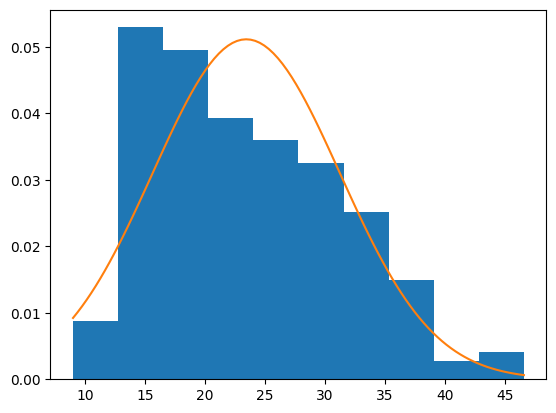

In [ ]:
mpg = df["mpg"]

mpg_x = np.linspace(mpg.min(),mpg.max(),100)
mpg_y = norm.pdf(mpg_x,mpg.mean(),mpg.std())

plt.hist(mpg,bins=10,density=True)
plt.plot(mpg_x,mpg_y)
plt.show()

## `MPG` outliers

In [ ]:
q1 = mpg.quantile(0.25)
q3 = mpg.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

is_out = (mpg < lower) | (mpg > upper)
df[is_out]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin


=> `mpg` has not outliers

## Correlations

In [ ]:
corr_mpg = df.corr(numeric_only=True)["mpg"].sort_values(ascending=False)
corr_mpg

,mpg
mpg,1.000000
model year,0.580541
origin,0.565209
acceleration,0.423329
cylinders,-0.777618
horsepower,-0.778427
displacement,-0.805127
weight,-0.832244


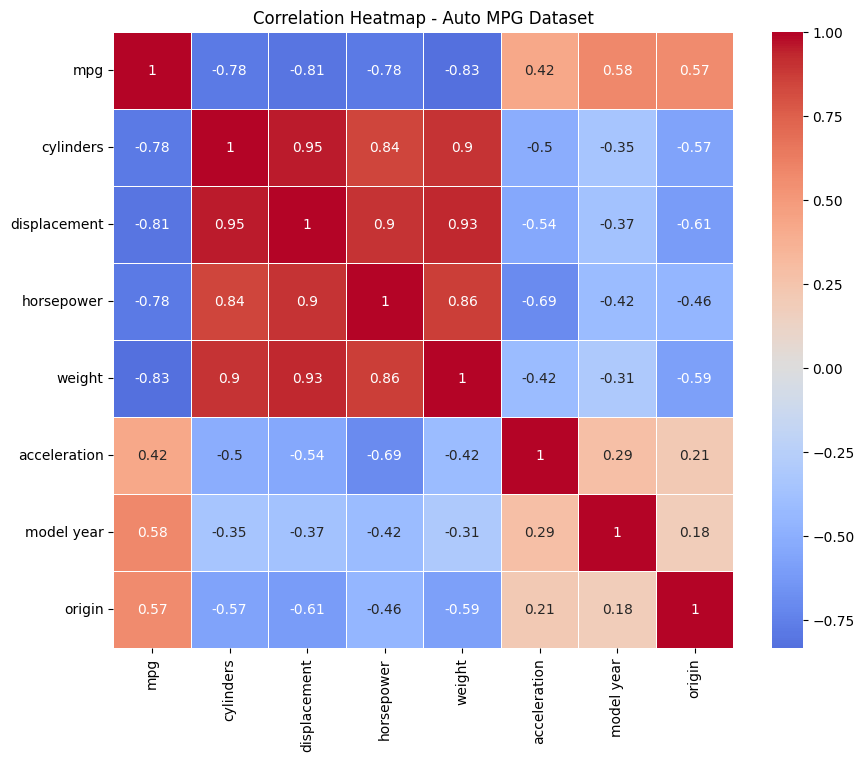

In [ ]:
corr_all = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_all,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap - Auto MPG Dataset")
plt.show()

## MPG vs other columns

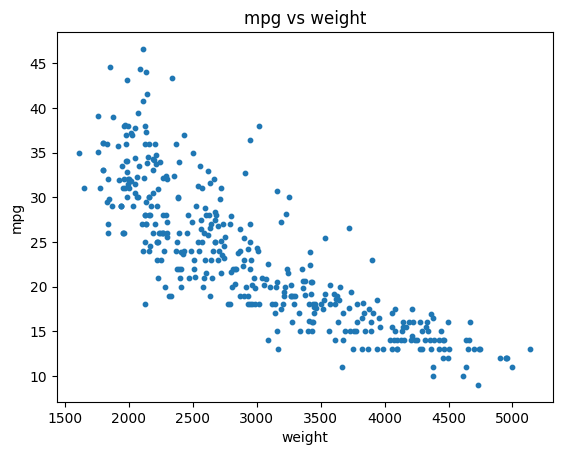

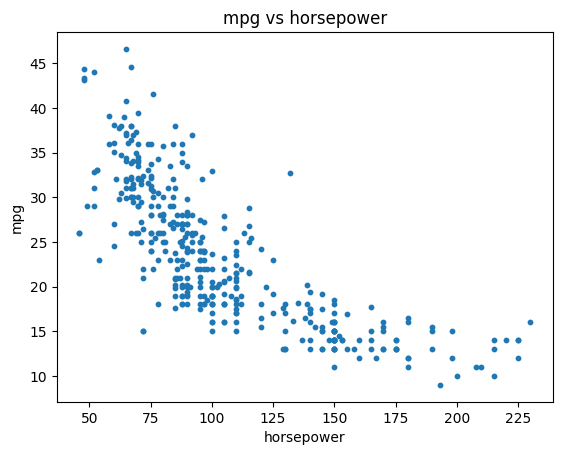

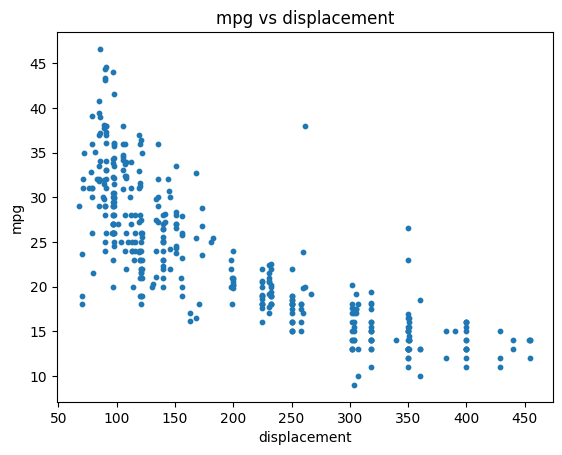

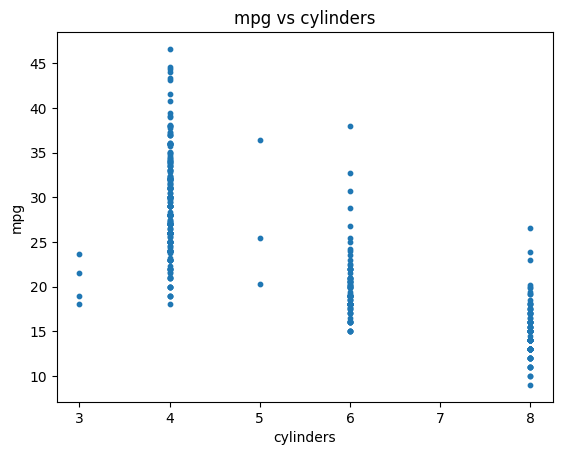

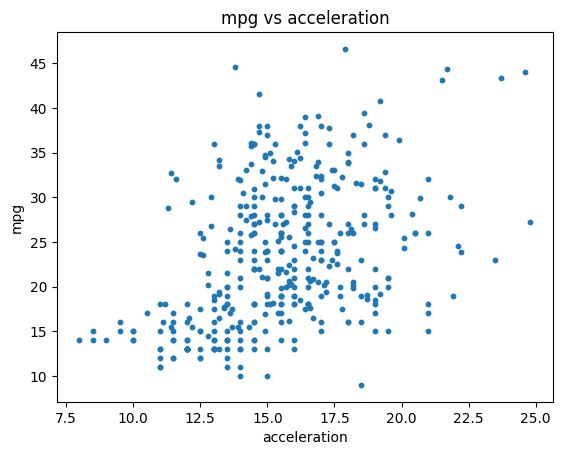

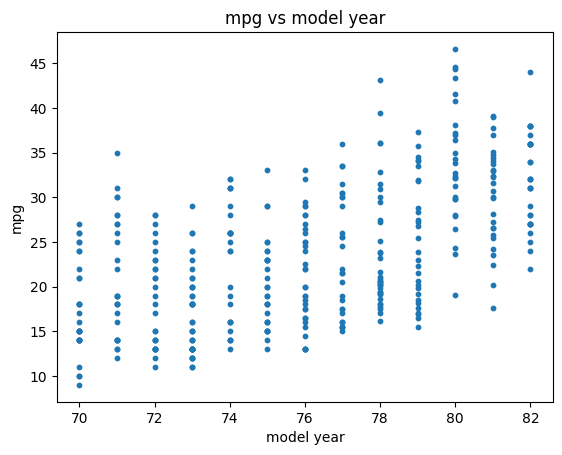

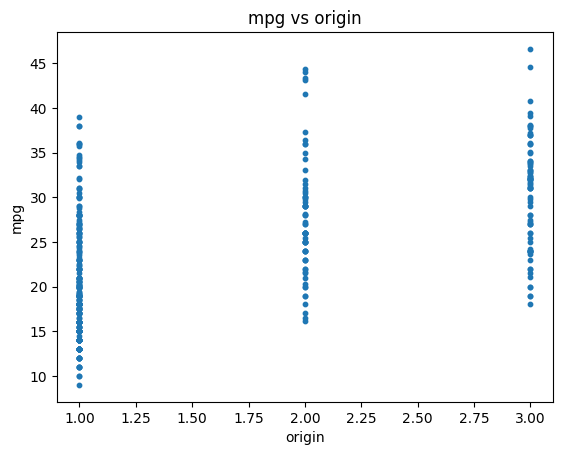

In [ ]:
features = ['weight', 'horsepower','displacement', 'cylinders', 'acceleration', 'model year', 'origin']

for col in features:
    plt.figure()
    plt.scatter(df[col],df["mpg"],s=10)
    plt.xlabel(col)
    plt.ylabel("mpg")
    plt.title(f"mpg vs {col}")
    plt.show()

EDA finished ✅

# Model Preparation

## train / test split

In [ ]:
X  = df[["weight"]].values
y = df["mpg"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42
)
print(f"{len(X)} total data, {len(X_train)} train data, {len(X_test)} test data.")

392 total data, 313 train data, 79 test data.


# Model Selection

## Simple Linear Regression

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))

print("== Simple LinearRegression ==")
print("RMSE Train: ", rmse_train)
print("RMSE Test: ", rmse_test)
print("Mean of mpg: ",y.mean())
print("R2 Score: ", r2_score(y_test,y_test_pred))

== Simple LinearRegression ==
RMSE Train:  4.364069911972353
RMSE Test:  4.206350944648542
Mean of mpg:  23.445918367346938
R2 Score:  0.6533466675646016


- ❌ overfitting
- ❌ leakage
- ✅ model is stable
- ✅ weight and mpg has real relation

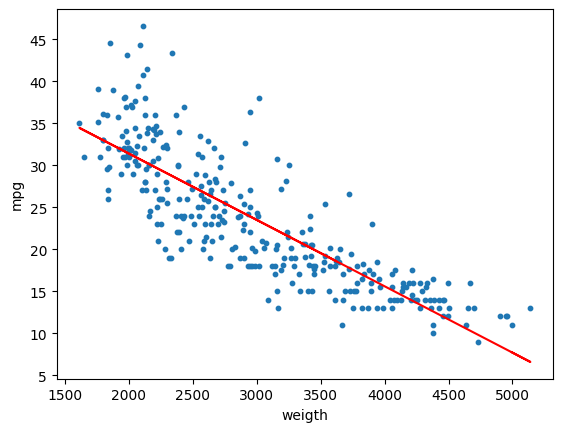

In [ ]:
plt.scatter(X_train, y_train,s=10,label="Train data")
plt.plot(X_train, y_train_pred,color="red",label="Linear fit")
plt.xlabel("weigth")
plt.ylabel("mpg")
plt.show()

In [ ]:
print(f"mpg = {round(lin_reg.coef_[0],4)} * weight + {round(lin_reg.intercept_,2)}")

mpg = -0.0079 * weight + 47.2


In [ ]:
sample_weight = 1000
sample_mpg = lin_reg.coef_[0] * sample_weight + lin_reg.intercept_
print(f"mpg of the car with {sample_weight} pounds is : ", round(sample_mpg,2))

mpg of the car with 1000 pounds is :  39.3


## Polynomial Linear Regression

In [ ]:
poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2,include_bias=False)),
    ("lin", LinearRegression())
])

poly.fit(X_train,y_train)

y_train_pred = poly.predict(X_train)
y_test_pred = poly.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))

print("== Polynomial LinearRegression ==")
print("RMSE Train: ", rmse_train)
print("RMSE Test: ", rmse_test)

== Polynomial LinearRegression ==
RMSE Train:  4.193204718772301
RMSE Test:  4.085226333510112


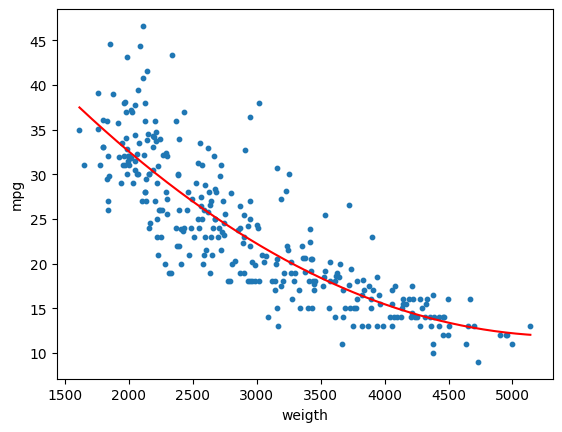

In [ ]:
x_plot = np.linspace(X_train.min(),X_train.max(),500).reshape(-1,1)
y_plot = poly.predict(x_plot)

plt.scatter(X_train, y_train,s=10,label="Train data")
plt.plot(x_plot, y_plot,color="red",label="Polynomial Linear fit")
plt.xlabel("weigth")
plt.ylabel("mpg")
plt.show()

## Multiple Linear Regression

### features

In [ ]:
features = [
    "weight",
    "displacement",
    "horsepower",
    "cylinders",
    "model year"
]

X = df[features].values
y = df["mpg"].values

### train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42
)
print(f"{len(X)} total data, {len(X_train)} train data, {len(X_test)} test data.")

392 total data, 313 train data, 79 test data.


### Model Preparation

In [ ]:
lin_multi = LinearRegression()
lin_multi.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_train_pred = lin_multi.predict(X_train)
y_test_pred = lin_multi.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))

print("== Multiple Linear Regression ==")
print("RMSE Train: ", rmse_train)
print("RMSE Test: ", rmse_test)

== Multiple Linear Regression ==
RMSE Train:  3.457543879636676
RMSE Test:  3.2491539021195033


In [ ]:
for f,c in zip(features,lin_multi.coef_):
    print(f"{f:15} : {c:.4f}")
print(f"intercept       : {round(lin_multi.intercept_,2)}")

weight          : -0.0064
displacement    : 0.0005
horsepower      : -0.0078
cylinders       : -0.1204
model year      : 0.7578
intercept       : -13.77


In [ ]:
c = lin_multi.coef_
print(f"y={c[0]:.4f}*weight + {c[1]:.4f}*displacement {c[2]:.4f}*horsepower {c[3]:.4f}*cylinders + {c[4]:.4f}*model_year {lin_multi.intercept_:.2f}")

y=-0.0064*weight + 0.0005*displacement -0.0078*horsepower -0.1204*cylinders + 0.7578*model_year -13.77


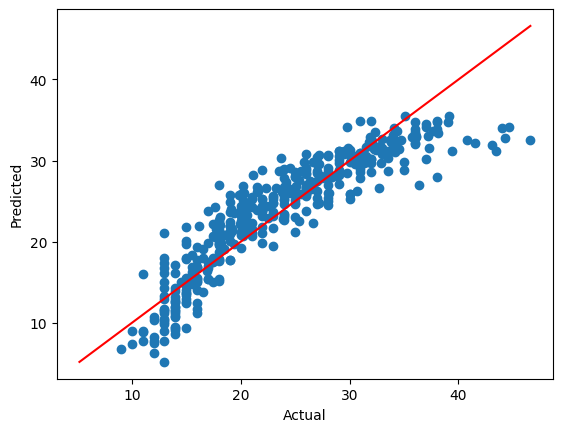

In [ ]:
y_pred = lin_multi.predict(X)

min_val = min(y.min(),y_pred.min())
max_val = max(y.max(),y_pred.max())

plt.scatter(y,y_pred)
plt.plot([min_val,max_val],[min_val,max_val],color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

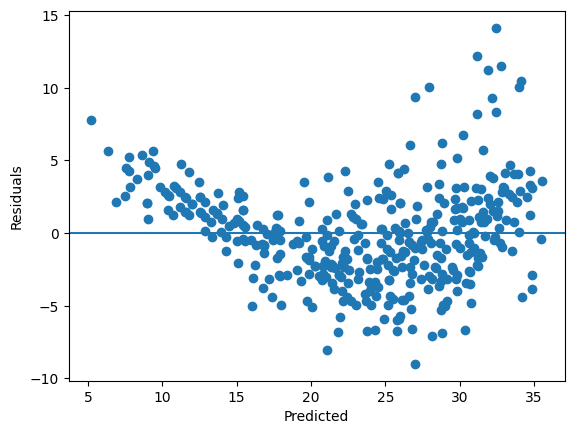

In [ ]:
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

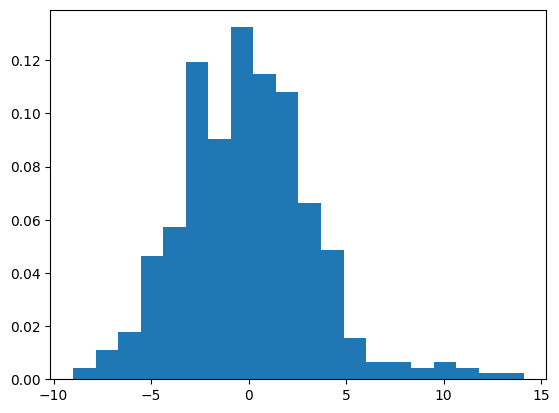

In [ ]:
plt.hist(residuals, bins=20,density=True)
plt.show()

# Regularization

## Multiple Linear Regression + Ridge (L2)

In [ ]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))

print("== Multiple Linear Regression + Ridge ==")
print("RMSE Train: ", rmse_train)
print("RMSE Test: ", rmse_test)

== Multiple Linear Regression + Ridge ==
RMSE Train:  3.457867951941682
RMSE Test:  3.252407427639381


In [ ]:
ridge_model = ridge.named_steps["ridge"]
for f,c in zip(features,ridge_model.coef_):
    print(f"{f:15} : {c:.4f}")
print(f"intercept       : {round(ridge_model.intercept_,2)}")

weight          : -5.2161
displacement    : -0.0471
horsepower      : -0.3200
cylinders       : -0.2130
model year      : 2.7284
intercept       : 23.6


## Multiple Linear Regression + Lasso (L1)

In [ ]:
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.05))
])

lasso.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.05))])

In [ ]:
y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))

print("== Multiple Linear Regression + Lasso ==")
print("RMSE Train: ", rmse_train)
print("RMSE Test: ", rmse_test)

== Multiple Linear Regression + Lasso ==
RMSE Train:  3.4581149043291113
RMSE Test:  3.236409274496112


In [ ]:
lasso_model = lasso.named_steps["lasso"]
for f,c in zip(features,lasso_model.coef_):
    print(f"{f:15} : {c:.4f}")
print(f"intercept       : {round(lasso_model.intercept_,2)}")

weight          : -5.3025
displacement    : -0.0000
horsepower      : -0.2855
cylinders       : -0.1676
model year      : 2.7094
intercept       : 23.6


## Multiple Linear Regression + Elastic Net

In [ ]:
elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(alpha=0.05,l1_ratio=0.5))
])

elastic.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('elastic', ElasticNet(alpha=0.05))])

In [ ]:
y_train_pred = elastic.predict(X_train)
y_test_pred = elastic.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))

print("== Multiple Linear Regression + Elastic Net ==")
print("RMSE Train: ", rmse_train)
print("RMSE Test: ", rmse_test)

== Multiple Linear Regression + Elastic Net ==
RMSE Train:  3.471555462929854
RMSE Test:  3.2639454875242073


In [ ]:
elastic_model = elastic.named_steps["elastic"]
for f,c in zip(features,elastic_model.coef_):
    print(f"{f:15} : {c:.4f}")
print(f"intercept       : {round(elastic_model.intercept_,2)}")

weight          : -4.5233
displacement    : -0.4702
horsepower      : -0.4617
cylinders       : -0.3227
model year      : 2.6049
intercept       : 23.6


# Residuals

In [ ]:
residuals_train = y_train - y_train_pred
residual_test = y_test - y_test_pred

## Residual vs Predicted

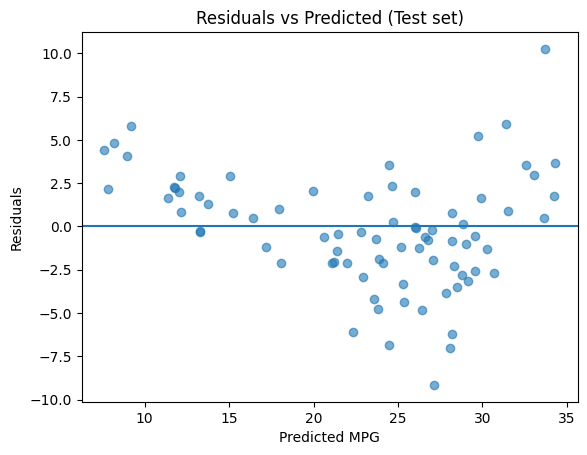

In [ ]:
plt.scatter(y_test_pred,residual_test,alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Test set)")
plt.show()

## Residual Distribution

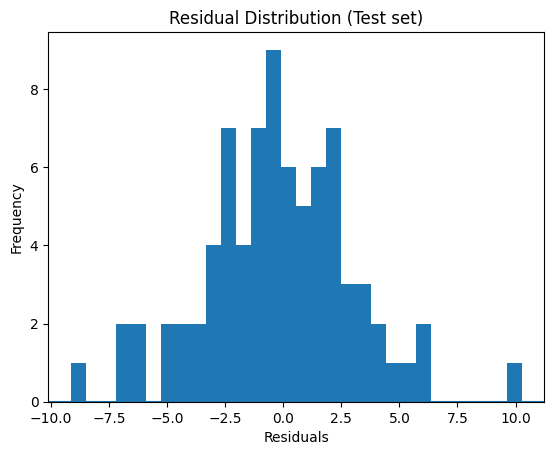

In [ ]:
plt.hist(residual_test,bins=30)
plt.axhline(0)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Test set)")
plt.show()

## Residual vs `Weight`

In [ ]:
features = [
    "weight",
    "displacement",
    "horsepower",
    "cylinders",
    "model year"
]

X_test_df = pd.DataFrame(X_test,columns=features)

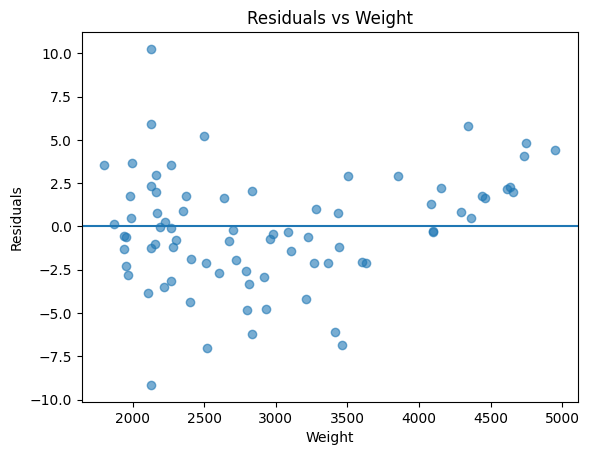

In [ ]:
plt.scatter(X_test_df["weight"],residual_test,alpha=0.6)
plt.axhline(0)
plt.xlabel("Weight")
plt.ylabel("Residuals")
plt.title("Residuals vs Weight")
plt.show()

## Residual vs `Model Year`

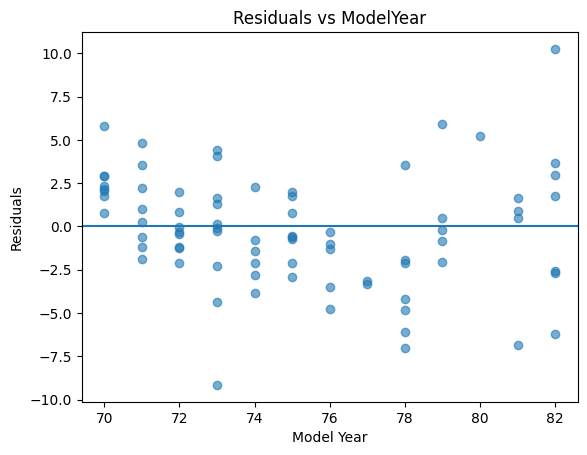

In [ ]:
plt.scatter(X_test_df["model year"],residual_test,alpha=0.6)
plt.axhline(0)
plt.xlabel("Model Year")
plt.ylabel("Residuals")
plt.title("Residuals vs ModelYear")
plt.show()

## Q-Q Plot of Residuals

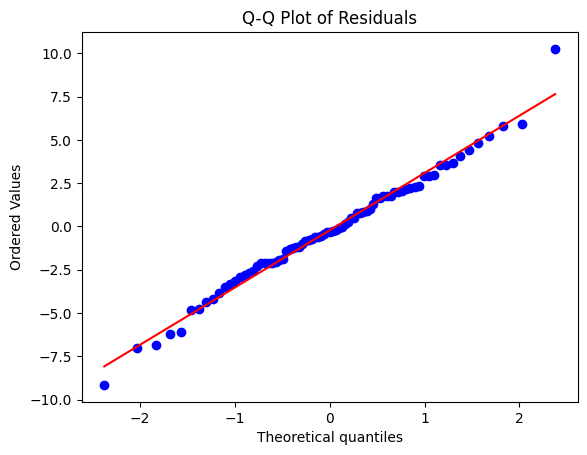

In [ ]:
stats.probplot(residual_test,plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Interactions
## Feature Engineering

In [ ]:
features

['weight', 'displacement', 'horsepower', 'cylinders', 'model year']

In [ ]:
X_train_df = pd.DataFrame(X_train,columns=features)
X_test_df = pd.DataFrame(X_test, columns=features)

X_train_interaction = X_train_df.copy()
X_test_interaction = X_test_df.copy()

X_train_interaction["weight_year"] = X_train_interaction["weight"] * X_train_interaction["model year"]
X_test_interaction["weight_year"] = X_test_interaction["weight"] * X_test_interaction["model year"]
X_train_interaction.head()

,weight,displacement,horsepower,cylinders,model year,weight_year
0,3620.0,225.0,110.0,6.0,78.0,282360.0
1,2572.0,140.0,92.0,4.0,76.0,195472.0
2,2984.0,171.0,97.0,6.0,75.0,223800.0
3,4135.0,318.0,150.0,8.0,72.0,297720.0
4,1875.0,86.0,64.0,4.0,81.0,151875.0


## Ridge + Interaction

In [ ]:
ridge_int = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_int.fit(X_train_interaction, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
y_train_pred_int = ridge_int.predict(X_train_interaction)
y_test_pred_int = ridge_int.predict(X_test_interaction)

rmse_train_int = np.sqrt(mean_squared_error(y_train,y_train_pred_int))
rmse_test_int = np.sqrt(mean_squared_error(y_test,y_test_pred_int))

print("== Ridge + Interaction (weight * year) ==")
print("RMSE Train: ", rmse_train_int)
print("RMSE Test: ", rmse_test_int)

== Ridge + Interaction (weight * year) ==
RMSE Train:  3.345606708624273
RMSE Test:  3.0866369271159515


In [ ]:
ridge_int_model = ridge_int.named_steps["ridge"]
for f,c in zip(X_train_interaction.columns,ridge_int_model.coef_):
    print(f"{f:15} : {c:.4f}")
print(f"intercept       : {round(elastic_model.intercept_,2)}")

weight          : 3.2271
displacement    : -0.0141
horsepower      : -0.5031
cylinders       : -0.0427
model year      : 4.0827
weight_year     : -8.1648
intercept       : 23.6


## Residuals

In [ ]:
residuals_test_int = y_test - y_test_pred_int

### Residuals vs Predicted

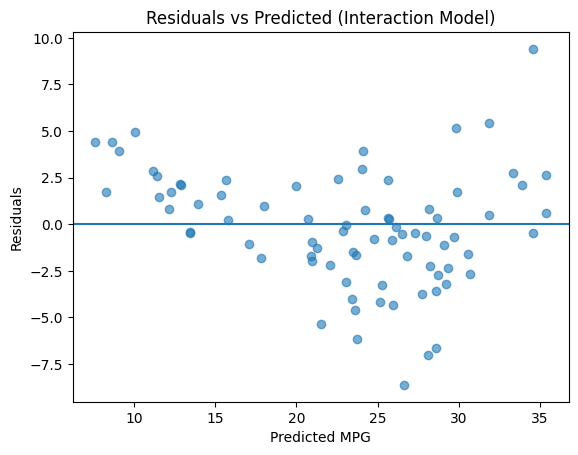

In [ ]:
plt.scatter(y_test_pred_int,residuals_test_int,alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Interaction Model)")
plt.show()

### Residual Distribution

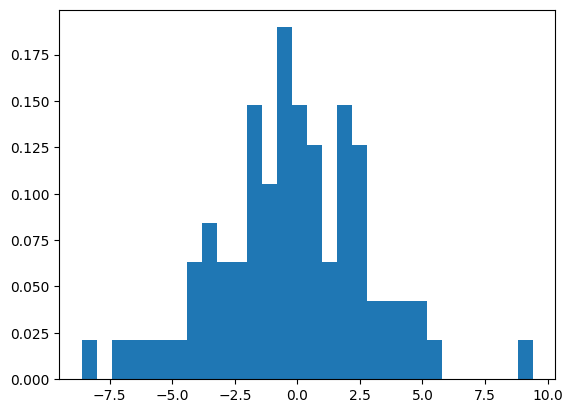

In [ ]:
plt.hist(residuals_test_int, bins=30,density=True)
plt.show()

### Residuals vs Weight

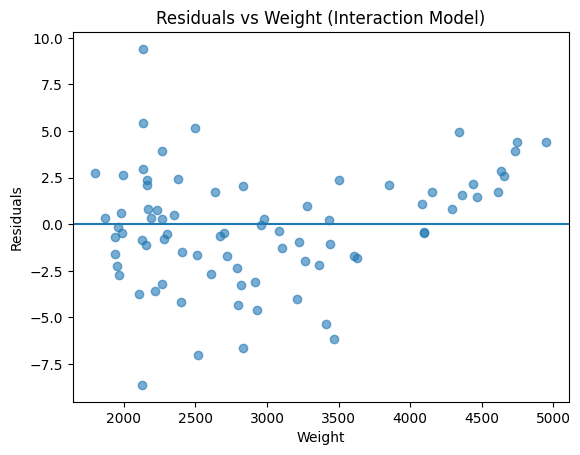

In [ ]:
plt.scatter(X_test_interaction["weight"],residuals_test_int,alpha=0.6)
plt.axhline(0)
plt.xlabel("Weight")
plt.ylabel("Residuals")
plt.title("Residuals vs Weight (Interaction Model)")
plt.show()

### Residuals vs ModelYear

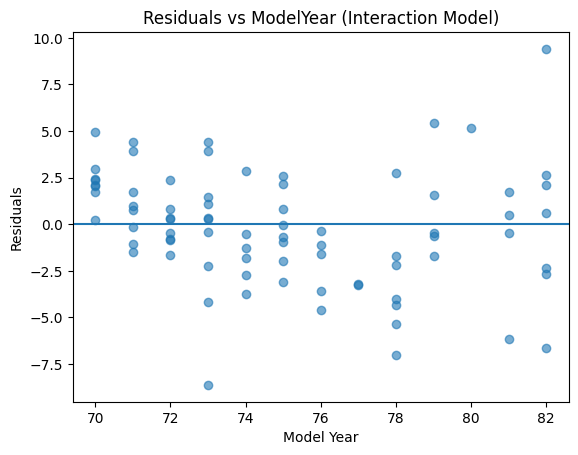

In [ ]:
plt.scatter(X_test_interaction["model year"],residuals_test_int,alpha=0.6)
plt.axhline(0)
plt.xlabel("Model Year")
plt.ylabel("Residuals")
plt.title("Residuals vs ModelYear (Interaction Model)")
plt.show()

### Q-Q Plot of Residuals

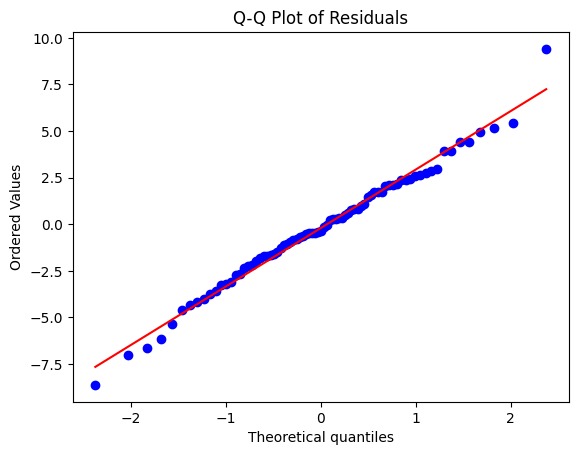

In [ ]:
stats.probplot(residuals_test_int,plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Testing new entry

In [ ]:
new_car = {
    "weight": 2800,
    "displacement": 140,
    "horsepower": 90,
    "cylinders": 4,
    "model year": 81
}

x_new = pd.DataFrame([new_car])
x_new["weight_year"] = x_new["weight"] * x_new["model year"]
x_new

,weight,displacement,horsepower,cylinders,model year,weight_year
0,2800,140,90,4,81,226800


In [ ]:
ridge_int.predict(x_new)

array([28.48777989])

In [ ]:
import os

notebook_name = "INTEL_UNNATI_Hyper-Efficiency Insights_Auto-MPG ML Project.ipynb"

if os.path.exists(notebook_name):
    print(f"The notebook '{notebook_name}' exists in the current directory.")
else:
    print(f"The notebook '{notebook_name}' DOES NOT exist in the current directory.")

The notebook 'INTEL_UNNATI_Hyper-Efficiency Insights_Auto-MPG ML Project.ipynb' DOES NOT exist in the current directory.
